# Shapefile Colombia por Municipios y Departamentos

DANE: https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/ 


In [20]:
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd
import warnings

warnings.filterwarnings('ignore')

shapefile_path = "../../datasets/shp/shp_DensProy_Mpio_2020_2035/DEPA_MPIO_20_35_GEOM1_GEOMETRIA.shp"
gdf = gpd.read_file(shapefile_path, encoding='latin-1')

print(gdf.shape)

gdf.head(5)

(1121, 100)


,COD_MPIO,COD_DPTO,AREA,POBTOT2020,DENTOT2020,POBTOT2021,DENTOT2021,POBTOT2022,DENTOT2022,POBTOT2023,...,DENRES2031,POBRES2032,DENRES2032,POBRES2033,DENRES2033,POBRES2034,DENRES2034,POBRES2035,DENRES2035,geometry
0,08549,08,252.928476,7008.0,27.71,7118.0,28.14,7207.0,28.49,7284.0,...,16.92,4305.0,17.05,4329.0,17.14,4348.0,17.22,4376.0,17.32,"POLYGON ((-75.12834 10.80752, -75.12839 10.807..."
1,08558,08,73.864331,19282.0,261.05,19606.0,265.43,19840.0,268.60,20038.0,...,48.49,3534.0,48.85,3569.0,49.33,3595.0,49.69,3617.0,50.00,"POLYGON ((-74.84353 10.81261, -74.84359 10.812..."
2,08560,08,206.535190,25378.0,122.87,25852.0,125.17,26184.0,126.78,26463.0,...,57.45,11845.0,57.84,11927.0,58.24,12015.0,58.67,12110.0,59.14,"POLYGON ((-74.87252 10.72105, -74.87255 10.721..."
3,08573,08,69.610922,52647.0,756.30,53716.0,771.66,54401.0,781.50,54983.0,...,129.09,7254.0,130.24,7327.0,131.55,7394.0,132.76,7463.0,133.99,"POLYGON ((-74.87272 11.04795, -74.87255 11.048..."
4,08606,08,358.540305,27729.0,77.34,28155.0,78.53,28493.0,79.47,28780.0,...,27.36,9832.0,27.59,9899.0,27.77,9981.0,28.00,10032.0,28.15,"POLYGON ((-75.05709 10.59342, -75.05729 10.593..."


## Diccionario de columnas (2026)

- **COD_DPTO**: Código del departamento (2 dígitos, según DANE).
- **COD_MPIO**: Código del municipio (3 dígitos, según DANE).
- **AREA**: Área del polígono (probablemente en metros cuadrados o kilómetros cuadrados, según la proyección).
- **geometry**: Polígono geométrico del municipio.

- **POBTOT2026**: Proyección de población total para el año 2026.
- **DENTOT2026**: Densidad total proyectada para 2026 (habitantes por unidad de área).
- **POBCAB2026**: Proyección de población en cabecera urbana para 2026.
- **DENCAB2026**: Densidad urbana proyectada para 2026.
- **POBRES2026**: Proyección de población en zona rural/resto para 2026.
- **DENRES2026**: Densidad rural proyectada para 2026.

In [21]:
# - Mantener solo las proyecciones para 2026 (y los identificadores / geometría)
COLUMNAS_2026 = [
    'COD_DPTO',
    'COD_MPIO',
    'AREA',
    'geometry',
    'POBTOT2026',
    'DENTOT2026',
    'POBCAB2026',
    'DENCAB2026',
    'POBRES2026',
    'DENRES2026'
]

gdf = gdf[COLUMNAS_2026].copy()
gdf.head(5)

,COD_DPTO,COD_MPIO,AREA,geometry,POBTOT2026,DENTOT2026,POBCAB2026,DENCAB2026,POBRES2026,DENRES2026
0,08,08549,252.928476,"POLYGON ((-75.12834 10.80752, -75.12839 10.807...",7395.0,29.24,3217.0,7518.53,4178.0,16.55
1,08,08558,73.864331,"POLYGON ((-74.84353 10.81261, -74.84359 10.812...",20423.0,276.49,17035.0,11197.81,3388.0,46.83
2,08,08560,206.535190,"POLYGON ((-74.87252 10.72105, -74.87255 10.721...",27020.0,130.83,15609.0,8864.72,11411.0,55.72
3,08,08573,69.610922,"POLYGON ((-74.87272 11.04795, -74.87255 11.048...",56118.0,806.17,49196.0,3535.62,6922.0,124.28
4,08,08606,358.540305,"POLYGON ((-75.05709 10.59342, -75.05729 10.593...",29325.0,81.79,19850.0,9341.68,9475.0,26.57


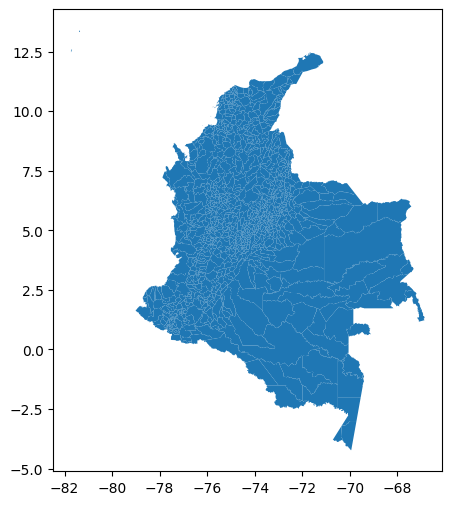

In [22]:
# Nivel 1 - Mapa básico con matplotlib usando la geometría de merged_full
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(ax=ax)
plt.show()

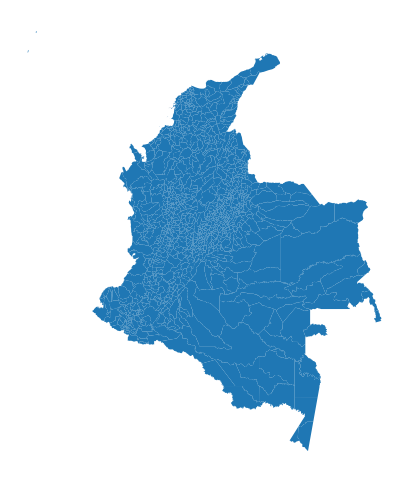

In [23]:
# Nivel 2 - Sin ejes
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(ax=ax)
ax.set_axis_off()
plt.show()

In [24]:
gdf.head()

,COD_DPTO,COD_MPIO,AREA,geometry,POBTOT2026,DENTOT2026,POBCAB2026,DENCAB2026,POBRES2026,DENRES2026
0,08,08549,252.928476,"POLYGON ((-75.12834 10.80752, -75.12839 10.807...",7395.0,29.24,3217.0,7518.53,4178.0,16.55
1,08,08558,73.864331,"POLYGON ((-74.84353 10.81261, -74.84359 10.812...",20423.0,276.49,17035.0,11197.81,3388.0,46.83
2,08,08560,206.535190,"POLYGON ((-74.87252 10.72105, -74.87255 10.721...",27020.0,130.83,15609.0,8864.72,11411.0,55.72
3,08,08573,69.610922,"POLYGON ((-74.87272 11.04795, -74.87255 11.048...",56118.0,806.17,49196.0,3535.62,6922.0,124.28
4,08,08606,358.540305,"POLYGON ((-75.05709 10.59342, -75.05729 10.593...",29325.0,81.79,19850.0,9341.68,9475.0,26.57


# Diccionario nombre Municipios y Departamentos

DANE: https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/ 

In [38]:
# - 
cod_mpio_dpto_df = pd.read_csv("../../datasets/varios/municipios_departamentos.csv")
cod_mpio_dpto_df['CODIGO_DPTO_MPIO'] = cod_mpio_dpto_df['CODIGO_DPTO_MPIO'].astype(str).str.zfill(5)

cod_mpio_dpto_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   CODIGO_DPTO_MPIO     1122 non-null   str  
 1   NOMBRE_MUNICIPIO     1122 non-null   str  
 2   NOMBRE_DEPARTAMENTO  1122 non-null   str  
dtypes: str(3)
memory usage: 26.4 KB


In [39]:
# - Validar filas

print("Filas en cod_mpio_dpto_df:", cod_mpio_dpto_df.shape)
print("Filas en gdf:", gdf.shape)

# - TODO: identifique que municipio falta y explique por que falta y como se puede solucionar el problema. (Hint: revise los codigos de municipio y departamento en ambos dataframes)

Filas en cod_mpio_dpto_df: (1122, 3)
Filas en gdf: (1121, 10)


In [42]:
# Unir dataframes 
colombia_gdf = gdf.merge(
    cod_mpio_dpto_df, 
    left_on=['COD_MPIO',], # Columnas en gdf
    right_on=['CODIGO_DPTO_MPIO'], # Columnas en cod_mpio_dpto_df
    how='left'
)

print(colombia_gdf.shape)
colombia_gdf.head()

(1121, 13)


,COD_DPTO,COD_MPIO,AREA,geometry,POBTOT2026,DENTOT2026,POBCAB2026,DENCAB2026,POBRES2026,DENRES2026,CODIGO_DPTO_MPIO,NOMBRE_MUNICIPIO,NOMBRE_DEPARTAMENTO
0,08,08549,252.928476,"POLYGON ((-75.12834 10.80752, -75.12839 10.807...",7395.0,29.24,3217.0,7518.53,4178.0,16.55,08549,PIOJÓ,ATLÁNTICO
1,08,08558,73.864331,"POLYGON ((-74.84353 10.81261, -74.84359 10.812...",20423.0,276.49,17035.0,11197.81,3388.0,46.83,08558,POLONUEVO,ATLÁNTICO
2,08,08560,206.535190,"POLYGON ((-74.87252 10.72105, -74.87255 10.721...",27020.0,130.83,15609.0,8864.72,11411.0,55.72,08560,PONEDERA,ATLÁNTICO
3,08,08573,69.610922,"POLYGON ((-74.87272 11.04795, -74.87255 11.048...",56118.0,806.17,49196.0,3535.62,6922.0,124.28,08573,PUERTO COLOMBIA,ATLÁNTICO
4,08,08606,358.540305,"POLYGON ((-75.05709 10.59342, -75.05729 10.593...",29325.0,81.79,19850.0,9341.68,9475.0,26.57,08606,REPELÓN,ATLÁNTICO


In [44]:
colombia_gdf = colombia_gdf[['COD_DPTO','COD_MPIO','NOMBRE_MUNICIPIO','NOMBRE_DEPARTAMENTO','AREA','POBTOT2026', 'DENTOT2026', 'POBCAB2026', 'DENCAB2026', 'POBRES2026', 'DENRES2026', 'geometry']]
colombia_gdf

,COD_DPTO,COD_MPIO,NOMBRE_MUNICIPIO,NOMBRE_DEPARTAMENTO,AREA,POBTOT2026,DENTOT2026,POBCAB2026,DENCAB2026,POBRES2026,DENRES2026,geometry
0,08,08549,PIOJÓ,ATLÁNTICO,252.928476,7395.0,29.24,3217.0,7518.53,4178.0,16.55,"POLYGON ((-75.12834 10.80752, -75.12839 10.807..."
1,08,08558,POLONUEVO,ATLÁNTICO,73.864331,20423.0,276.49,17035.0,11197.81,3388.0,46.83,"POLYGON ((-74.84353 10.81261, -74.84359 10.812..."
2,08,08560,PONEDERA,ATLÁNTICO,206.535190,27020.0,130.83,15609.0,8864.72,11411.0,55.72,"POLYGON ((-74.87252 10.72105, -74.87255 10.721..."
3,08,08573,PUERTO COLOMBIA,ATLÁNTICO,69.610922,56118.0,806.17,49196.0,3535.62,6922.0,124.28,"POLYGON ((-74.87272 11.04795, -74.87255 11.048..."
4,08,08606,REPELÓN,ATLÁNTICO,358.540305,29325.0,81.79,19850.0,9341.68,9475.0,26.57,"POLYGON ((-75.05709 10.59342, -75.05729 10.593..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1116,91,91530,PUERTO ALEGRÍA (ANM),AMAZONAS,8494.182494,809.0,0.10,0.0,NaN,809.0,0.10,"POLYGON ((-73.60741 -0.70392, -73.64995 -0.648..."
1117,91,91536,PUERTO ARICA (ANM),AMAZONAS,13791.326986,1131.0,0.08,0.0,NaN,1131.0,0.08,"POLYGON ((-71.18864 -1.38937, -71.19036 -1.387..."
1118,91,91540,PUERTO NARIÑO,AMAZONAS,1509.204361,11173.0,7.40,4667.0,7003.35,6506.0,4.30,"POLYGON ((-70.36439 -3.69037, -70.36467 -3.690..."
1119,91,91669,PUERTO SANTANDER (ANM),AMAZONAS,14731.088495,2016.0,0.14,0.0,NaN,2016.0,0.14,"POLYGON ((-71.9961 -0.32398, -71.9961 -0.32385..."


# Retomamos nuestra renderizacion del mapa

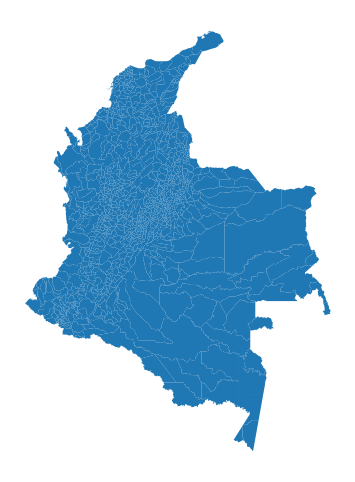

In [45]:
# Nivel 3 - Quitar San Andrés y Providencia (departamento 88) y graficar
# Algunas fuentes usan código 88 para el departamento de San Andrés, Providencia y Santa Catalina

remover_dpto = ['88']

colombia_gdf_no_sap = colombia_gdf[~colombia_gdf['COD_DPTO'].astype(str).str.zfill(2).isin(remover_dpto)]

fig, ax = plt.subplots(figsize=(10, 6))
colombia_gdf_no_sap.plot(ax=ax)
ax.set_axis_off()
plt.show()


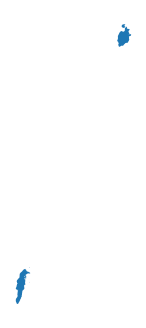

In [46]:
# Filtrar únicamente el departamento 88 (San Andrés y Providencia)
san_andres = colombia_gdf[
    colombia_gdf['COD_DPTO'].astype(str).str.zfill(2) == '88'
]

fig, ax = plt.subplots(figsize=(8,4))
san_andres.plot(ax=ax)
ax.set_axis_off()

plt.show()

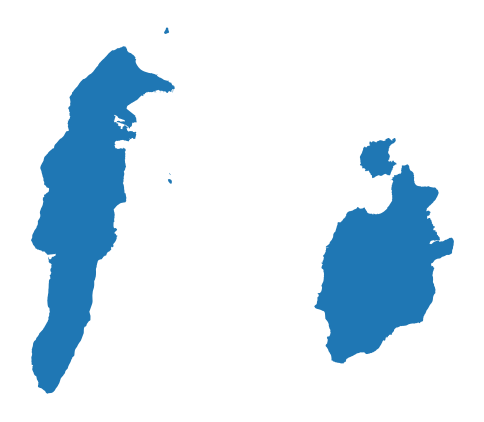

In [47]:
from shapely.affinity import translate

# Filtrar el departamento 88
san_andres = colombia_gdf[
    colombia_gdf['COD_DPTO'].astype(str).str.zfill(2) == '88'
].copy()

# Centroides
san_andres["cx"] = san_andres.geometry.centroid.x
san_andres["cy"] = san_andres.geometry.centroid.y

# Identificar islas
san_andres_isla = san_andres.loc[san_andres["cx"].idxmin()]
providencia = san_andres.loc[san_andres["cx"].idxmax()]

# posición objetivo (más cerca y más abajo)
target_x = san_andres_isla["cx"] + 0.10
target_y = san_andres_isla["cy"] - 0.02

# Desplazamiento
dx = target_x - providencia["cx"]
dy = target_y - providencia["cy"]

# Trasladar Providencia
providencia_geom = translate(providencia.geometry, xoff=dx, yoff=dy)

# Crear GeoDataFrame ajustado
adjusted = gpd.GeoDataFrame(
    geometry=[san_andres_isla.geometry, providencia_geom],
    crs=san_andres.crs
)

# Graficar
fig, ax = plt.subplots(figsize=(6,6))

adjusted.plot(ax=ax)

ax.set_axis_off()

plt.show()

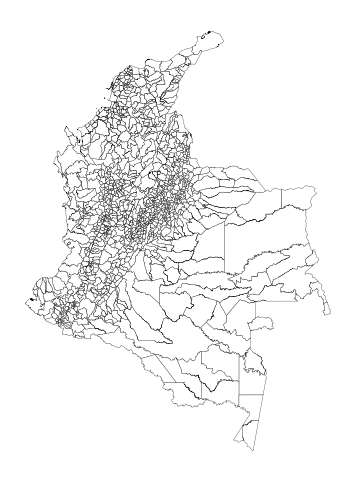

In [48]:
# Nivel 4 - Quitar San Andrés y graficar en blanco

fig, ax = plt.subplots(figsize=(10, 6))

colombia_gdf_no_sap.plot(
    ax=ax,
    color="white",        # relleno blanco
    edgecolor="black",    # borde negro -- edgecolor="#444444"
    linewidth=0.2          # grosor del borde más delgado
)

ax.set_axis_off()

plt.show()

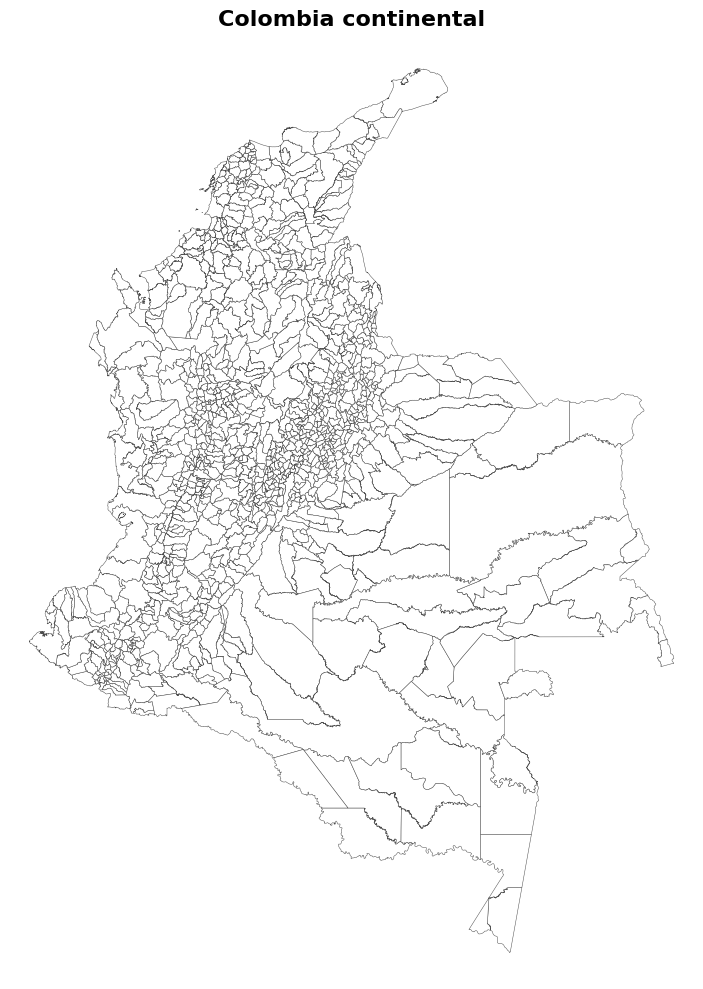

In [49]:
# Nivel 5 - Base cartográfica profesional sin San Andrés y Providencia



fig, ax = plt.subplots(figsize=(9, 10))

# Fondo del eje
ax.set_facecolor("#f7f7f7")

# Graficar mapa
colombia_gdf_no_sap.plot(
    ax=ax,
    color="white",          # relleno del país
    edgecolor="#4d4d4d",    # bordes gris oscuro, más elegantes que negro puro
    linewidth=0.35
)

# Quitar ejes
ax.set_axis_off()

# Mantener proporción geográfica
ax.set_aspect("equal")

# Ajustar límites para encuadrar mejor Colombia continental
minx, miny, maxx, maxy = colombia_gdf_no_sap.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# Título opcional
ax.set_title("Colombia continental", fontsize=16, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

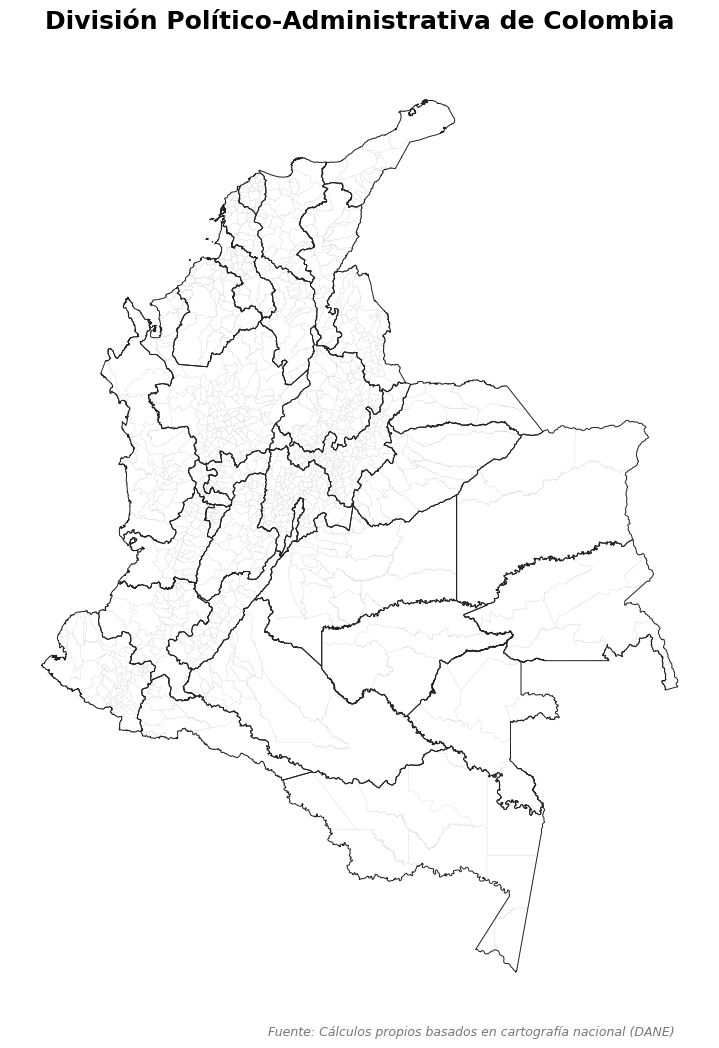

In [51]:
# Nivel 6
# --- PASO PREVIO: Crear el contorno de los departamentos ---
# Disolvemos los municipios basándonos en el código o nombre del departamento
depts_gdf = colombia_gdf_no_sap.dissolve(by='NOMBRE_DEPARTAMENTO')

# --- CONFIGURACIÓN DEL MAPA ---
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_facecolor("#ffffff") # Blanco puro para exportación limpia

# 1. Capa de MUNICIPIOS
colombia_gdf_no_sap.plot(
    ax=ax,
    color="white",
    edgecolor="#cccccc",    # Gris muy claro
    linewidth=0.15,
    zorder=1
)

# 2. Capa de DEPARTAMENTOS
depts_gdf.geometry.boundary.plot(
    ax=ax,
    edgecolor="#222222",    # Un poco más oscuro para que resalte
    linewidth=0.7,
    zorder=2
)

# --- ESTÉTICA FINAL ---
ax.set_axis_off()
ax.set_aspect("equal")

# Título mejor posicionado
ax.set_title(
    "División Político-Administrativa de Colombia", 
    fontsize=18, 
    fontweight="bold", 
    pad=20
)

# SOLUCIÓN A LA FUENTE: 
# Usamos transform=ax.transAxes para que (1,0) sea la esquina inferior derecha del mapa
ax.text(
    0.95, -0.02, 
    'Fuente: Cálculos propios basados en cartografía nacional (DANE)', 
    transform=ax.transAxes, 
    ha='right', 
    fontsize=9, 
    color='#777777',
    style='italic'
)

# Ajuste manual de los márgenes para que nada se corte
plt.subplots_adjust(bottom=0.1, top=0.9) 

plt.show()

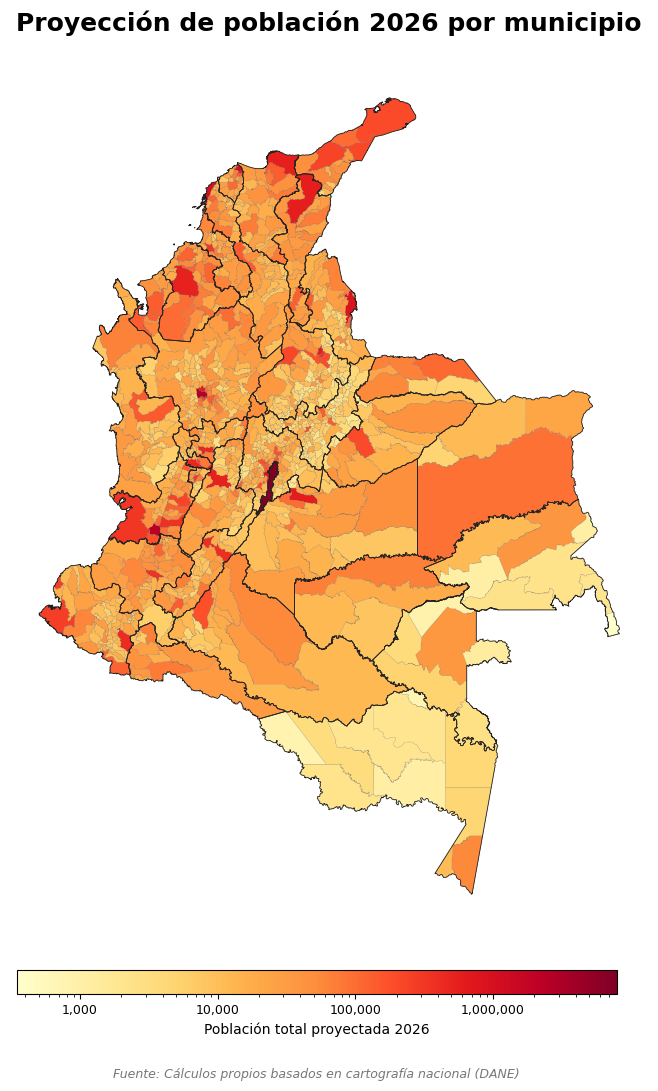

In [55]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker

# 1. PREPARACIÓN DE DATOS
# Convertimos la columna a numérico y manejamos valores nulos o en cero
# El LogNorm fallará si encuentra ceros, por eso usamos el mínimo valor mayor a cero
pop = colombia_gdf_no_sap["POBTOT2026"].fillna(0).astype(float)
min_nonzero = pop[pop > 0].min() if (pop > 0).any() else 1
max_val = pop.max()

# Definimos la normalización logarítmica
norm = mpl.colors.LogNorm(vmin=min_nonzero, vmax=max_val)

# 2. CREACIÓN DE LA FIGURA
fig, ax = plt.subplots(figsize=(10, 12))

# 3. DIBUJO DEL MAPA TEMÁTICO (CHOROPLETH)
# Graficamos los municipios usando la escala de colores 'YlOrRd' (Amarillo-Naranja-Rojo)
map_plot = colombia_gdf_no_sap.plot(
    column="POBTOT2026",
    cmap="YlOrRd",
    norm=norm,
    linewidth=0.1,
    edgecolor="#555555",
    ax=ax,
    zorder=1,
)

# 4. CAPA DE DEPARTAMENTOS
# Dibujamos solo los bordes de los departamentos para dar contexto geográfico
depts_gdf.geometry.boundary.plot(
    ax=ax,
    edgecolor="#222222",
    linewidth=0.6,
    zorder=2
)

# 5. CONFIGURACIÓN DE LA BARRA DE COLORES (COLORBAR)
# La creamos manualmente para tener control total sobre las etiquetas (ticks)
cax = fig.add_axes([0.2, 0.1, 0.6, 0.02]) # [izquierda, abajo, ancho, alto]
cb = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap="YlOrRd"),
    cax=cax,
    orientation='horizontal',
    label='Población total proyectada 2026'
)

# Formateamos los números para que no salgan como potencias de 10 confusas
# Usamos ScalarFormatter para ver números reales (1.000, 10.000, etc.)
cb.ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
cb.ax.tick_params(labelsize=9)

# 6. ESTÉTICA FINAL Y TEXTOS
ax.set_axis_off() # Quitamos los ejes de coordenadas (latitud/longitud)
ax.set_aspect("equal")

# Título principal
ax.set_title(
    "Proyección de población 2026 por municipio",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

# Fuente de datos - Ajustamos la posición 'y' para que esté debajo de la barra de colores
fig.text(
    0.5, 0.03, 
    "Fuente: Cálculos propios basados en cartografía nacional (DANE)",
    ha="center", 
    fontsize=9, 
    color="#777777", 
    style="italic"
)

# Ajuste manual para que nada se corte
plt.subplots_adjust(bottom=0.15)
plt.show()

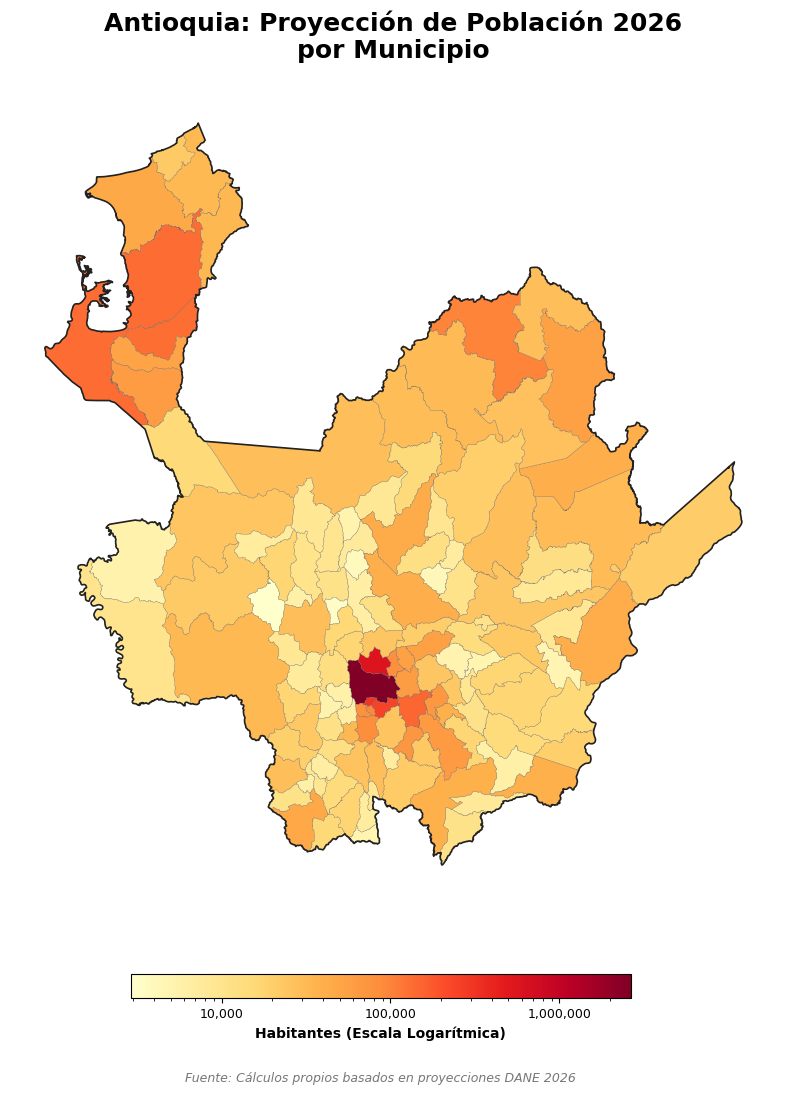

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker

# --- PASO 1: FILTRADO DE DATOS ---
# Al encadenar métodos, necesitamos invocar .str cada vez que usemos una función de texto
antioquia_gdf = colombia_gdf_no_sap[
    colombia_gdf_no_sap["NOMBRE_DEPARTAMENTO"]
    .str.upper()        # Convertimos a mayúsculas
    .str.contains("ANTIOQUIA") # Filtramos antioquia
].copy()

# --- PASO 2: NORMALIZACIÓN LOGARÍTMICA ---
pop_ant = antioquia_gdf["POBTOT2026"].fillna(0).astype(float)
min_val = pop_ant[pop_ant > 0].min() if (pop_ant > 0).any() else 1
max_val = pop_ant.max()
norm_ant = mpl.colors.LogNorm(vmin=min_val, vmax=max_val)

# --- PASO 3: CREACIÓN DEL LIENZO ---
fig, ax = plt.subplots(figsize=(10, 12))

# Dibujo de municipios
antioquia_gdf.plot(
    column="POBTOT2026",
    cmap="YlOrRd",
    norm=norm_ant,
    linewidth=0.2,
    edgecolor="#666666",
    ax=ax,
    zorder=1
)

# --- PASO 4: MARCO DEL DEPARTAMENTO ---
antioquia_gdf.dissolve().geometry.boundary.plot(
    ax=ax,
    edgecolor="#222222",
    linewidth=1.2,
    zorder=2
)

# --- PASO 5: BARRA DE COLORES (COLORBAR) ---
cax = fig.add_axes([0.25, 0.12, 0.5, 0.02]) 
cb = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm_ant, cmap="YlOrRd"),
    cax=cax,
    orientation='horizontal'
)

cb.set_label('Habitantes (Escala Logarítmica)', fontsize=10, fontweight='bold')
cb.ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=5))
cb.ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
cb.ax.tick_params(labelsize=9)

# --- PASO 6: ESTÉTICA Y FUENTE ---
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_title(
    "Antioquia: Proyección de Población 2026\npor Municipio",
    fontsize=18,
    fontweight="bold",
    pad=20,
)

fig.text(
    0.5, 0.05, 
    "Fuente: Cálculos propios basados en proyecciones DANE 2026",
    ha="center", fontsize=9, color="#777777", style="italic"
)

plt.subplots_adjust(bottom=0.2)
plt.show()